In [ ]:
import os, shutil, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize as MplNormalize

shutil.rmtree('__pycache__', ignore_errors=True)
from index import SyntheticGenerator
from utils.index import *

In [ ]:
def show3DCube(ax, volume, label, x_ratio=0.1, y_ratio=0.9, z_ratio=0.9, stride=1):
    nx, ny, nz = volume.shape
    pos_x, pos_y, pos_z = int(nx * x_ratio), int(ny * y_ratio), int(nz * z_ratio)

    cmap = plt.cm.gray
    norm = MplNormalize(vmin=volume.min(), vmax=volume.max())

    def plot_plane(axis_to_fix, fixed_pos):
        if axis_to_fix == 'y':    # Plano XZ
            ranges_dim1 = [(0, pos_x + 1), (pos_x, nx)]
            ranges_dim2 = [(0, pos_z + 1), (pos_z, nz)]
        elif axis_to_fix == 'x':  # Plano YZ
            ranges_dim1 = [(0, pos_y + 1), (pos_y, ny)]
            ranges_dim2 = [(0, pos_z + 1), (pos_z, nz)]
        else:                     # Plano XY (z)
            ranges_dim1 = [(0, pos_x + 1), (pos_x, nx)]
            ranges_dim2 = [(0, pos_y + 1), (pos_y, ny)]

        for start1, end1 in ranges_dim1:
            for start2, end2 in ranges_dim2:
                arr1, arr2 = np.arange(start1, end1), np.arange(start2, end2)

                if axis_to_fix == 'y':
                    X, Z = np.meshgrid(arr1, arr2, indexing='ij')
                    Y = np.full_like(X, fixed_pos)
                    Z_plot = nz - Z
                    data = volume[start1:end1, fixed_pos, start2:end2]
                elif axis_to_fix == 'x':
                    Y, Z = np.meshgrid(arr1, arr2, indexing='ij')
                    X = np.full_like(Y, fixed_pos)
                    Z_plot = nz - Z
                    data = volume[fixed_pos, start1:end1, start2:end2]
                else:
                    X, Y = np.meshgrid(arr1, arr2, indexing='ij')
                    Z_plot = np.full_like(X, nz - fixed_pos)
                    data = volume[start1:end1, start2:end2, fixed_pos]

                ax.plot_surface(X, Y, Z_plot, facecolors=cmap(norm(data)), shade=False, antialiased=False, linewidth=0, rstride=stride, cstride=stride)

    plot_plane('y', pos_y) # Parede XZ
    plot_plane('x', pos_x) # Parede YZ
    plot_plane('z', pos_z) # Chão XY

    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(0, nz)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.set_title(label, fontsize=14, fontweight='bold', loc='left')
    ax.view_init(elev=20, azim=-45)


def showSteps(steps, save=None):
    fig = plt.figure(figsize=(18, 12))
    for i, (volume, label) in enumerate(steps):
        ax = fig.add_subplot(2, 3, i + 1, projection='3d')
        show3DCube(ax, volume, label)
        
    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)

    plt.show()

# Visualização 3D Step-by-Step
Cada subplot mostra um passo do pipeline de geração sísmica como um cubo 3D com 3 faces visíveis (back wall, side wall, floor).

- **a) Reflectivity** — Camadas horizontais planas
- **b) Folding** — Dobramentos Gaussianos
- **c) Shearing** — Cisalhamento/inclinação planar
- **d) Faulting** — Falhas com deslocamento
- **e) Wavelet** — Convolução com wavelet de Ricker
- **f) Noise** — Ruído gaussiano adicionado

In [ ]:
best_options = {
    "layerRange": [
        59,
        293
    ],
    "layerThickness": [
        2,
        3
    ],
    "foldCount": [
        7,
        29
    ],
    "foldSigma": [
        17,
        38
    ],
    "foldAmplitude": [
        -8,
        14
    ],
    "foldDamping": 1.9652891134338613,
    "foldBaseShift": [
        -1.7817678515388828,
        1.7247333198050963
    ],
    "shearOffset": [
        -3.9812052831914704,
        1.711522334413226
    ],
    "shearGradient": [
        -0.09685666356598369,
        0.1563808918844276
    ],
    "faultCount": [
        4,
        7
    ],
    "faultThrow": [
        5,
        25
    ],
    "faultDipAngle": [
        49,
        82
    ],
    "faultRoughness": 2.32249458174305,
    "faultRoughSigma": 3.0014368447712862,
    "faultDecaySigma": [
        34,
        83
    ],
    "faultZoneWidth": 1.0219748559945656,
    "faultThreshold": 0.6992326649782601,
    "faultCurveProb": 0.24581120923818361,
    "faultCurveMax": 3.1492397419531653,
    "waveletFreq": [
        69,
        97
    ],
    "waveletDuration": 0.06604178041012981,
    "waveletDt": 0.009708596957033785,
    "noiseLevel": [
        0,
        0.15563172083662333
    ]
}

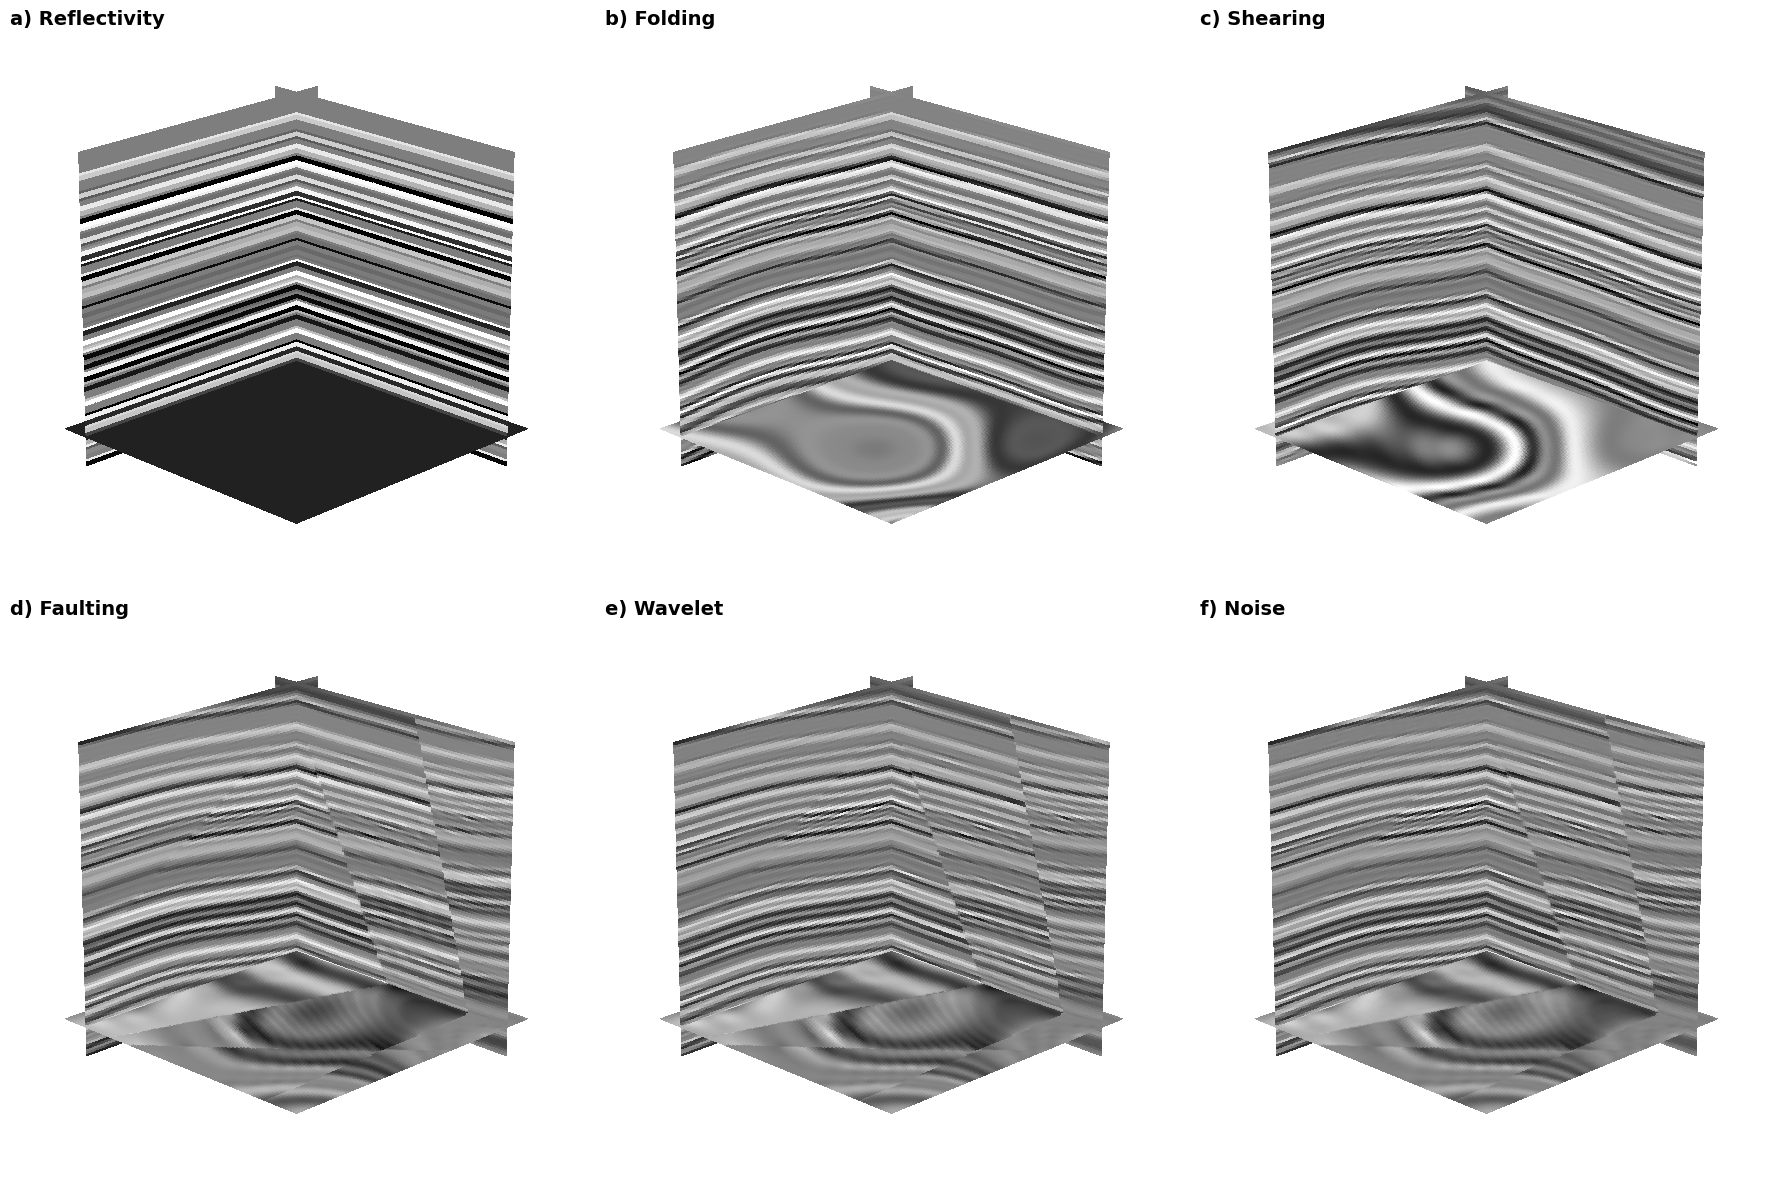

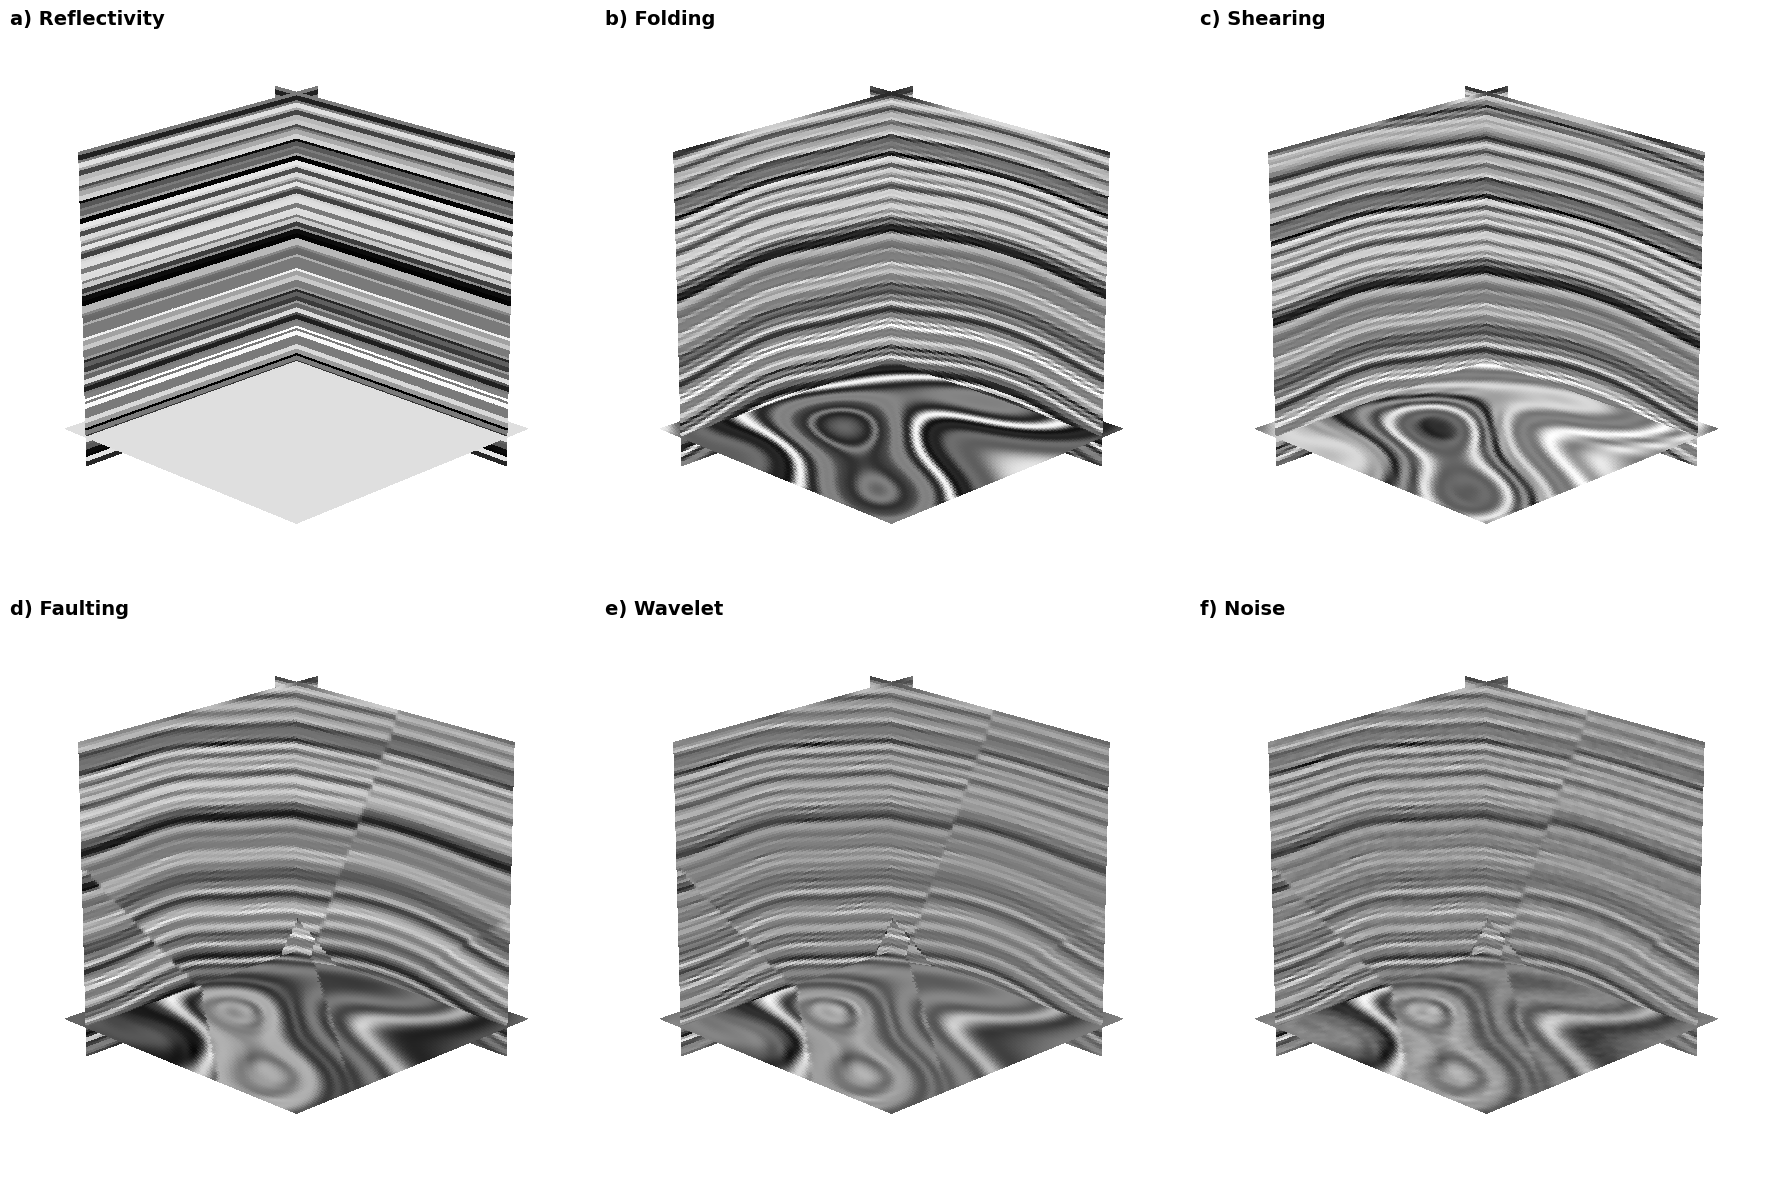

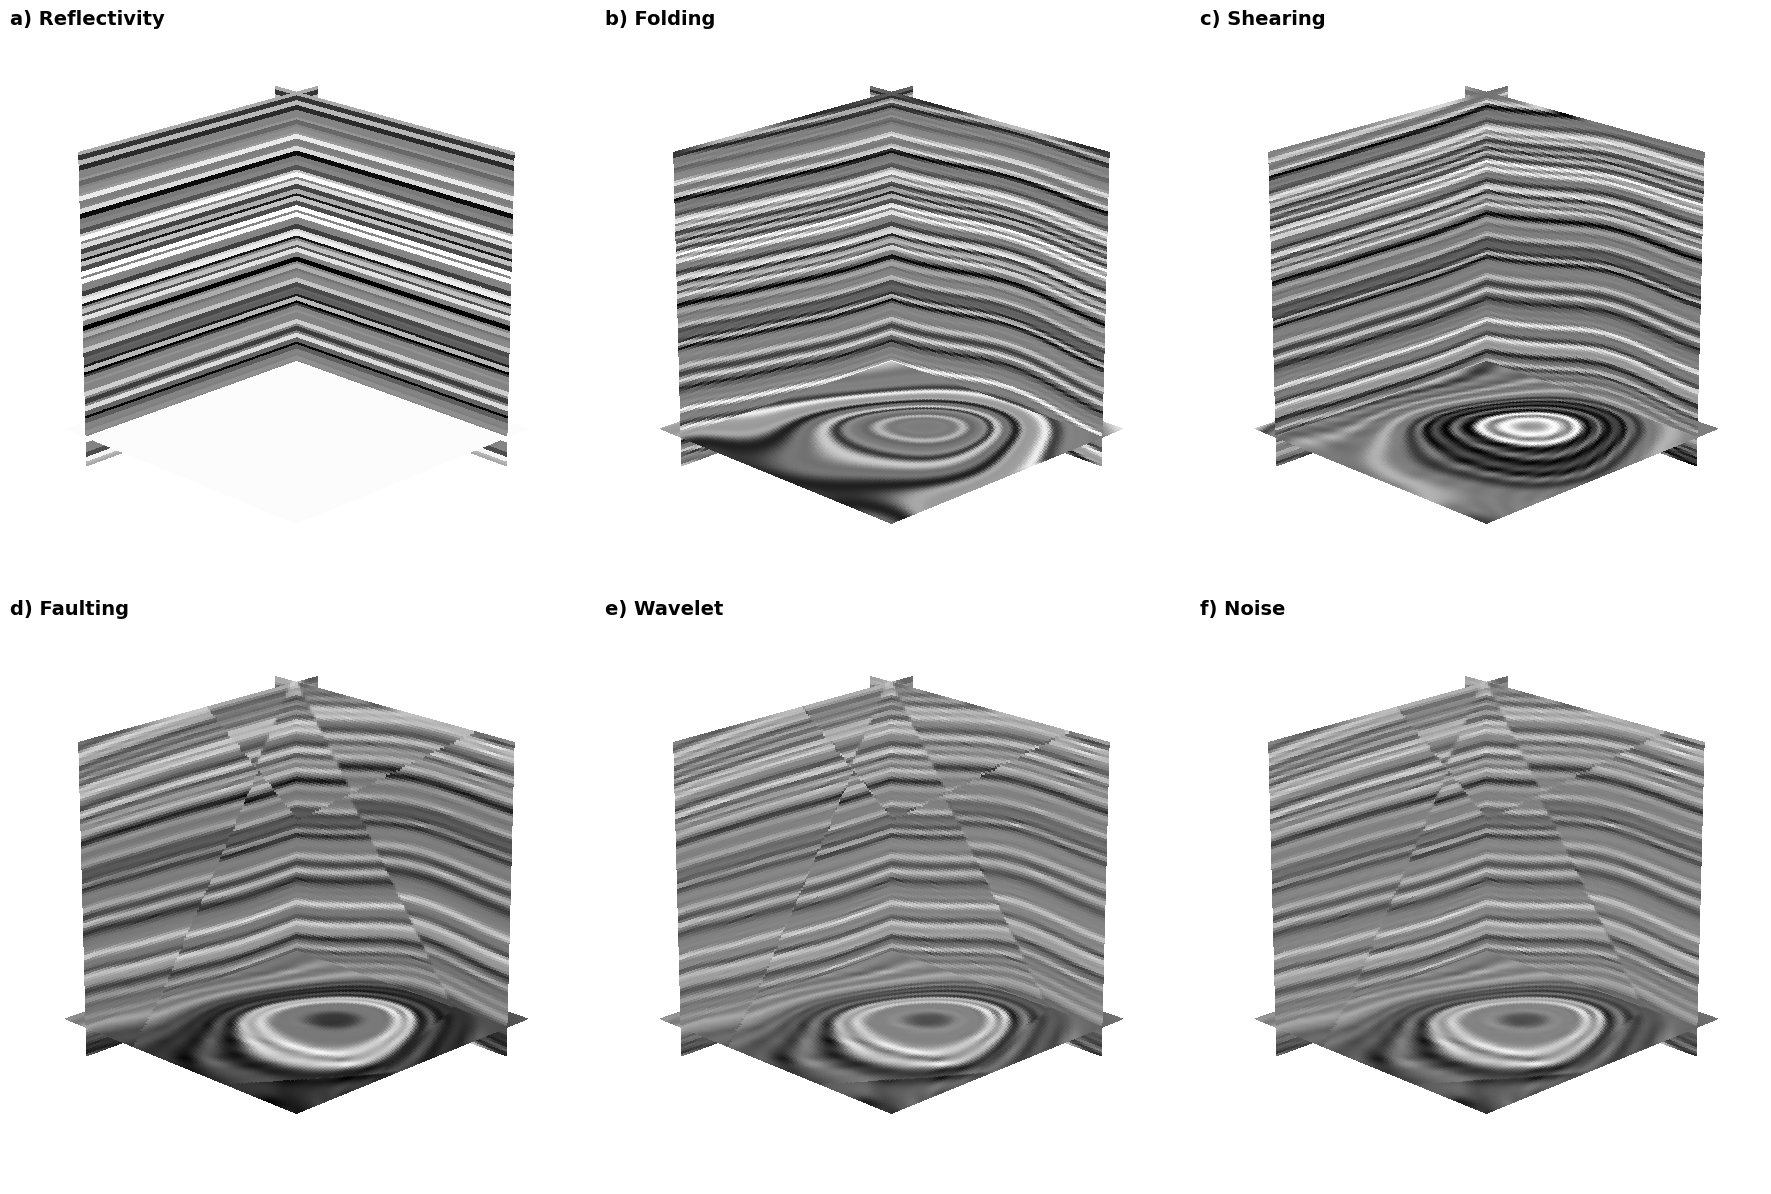

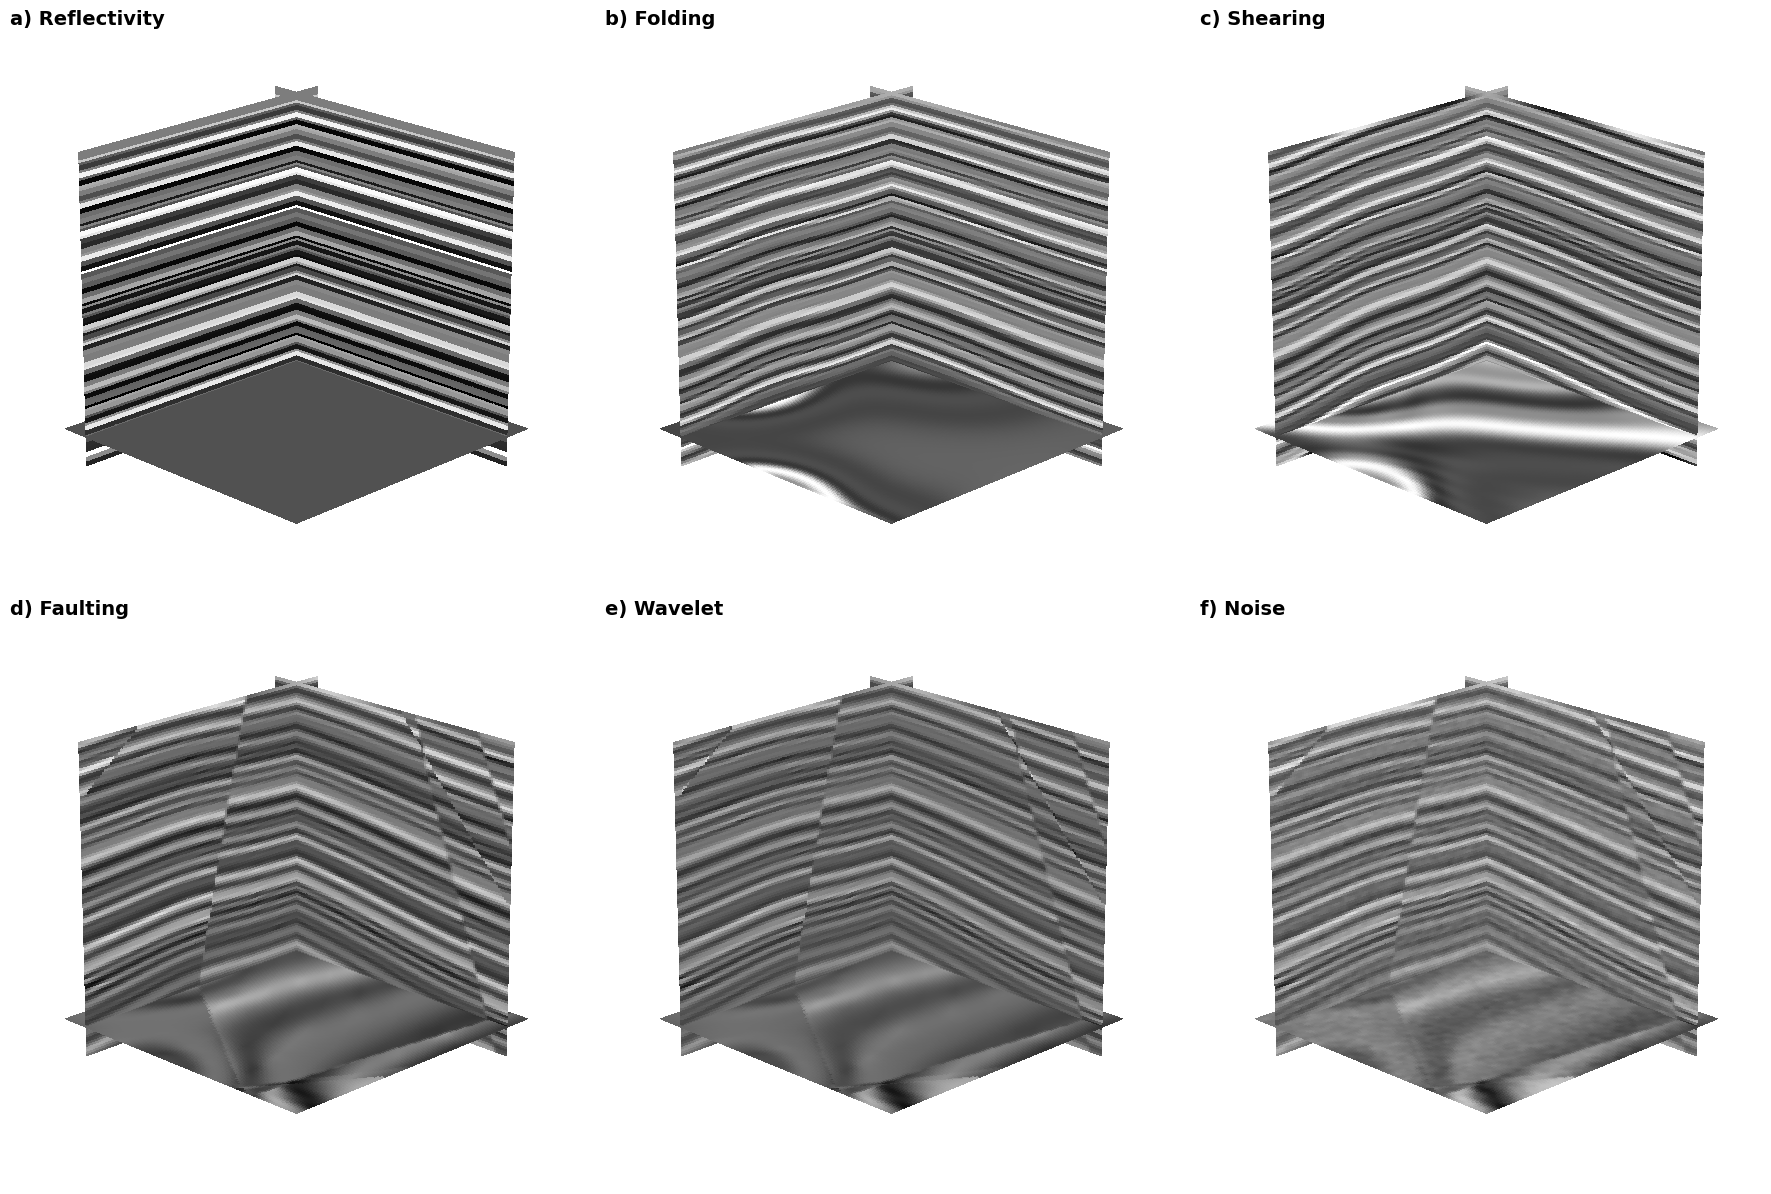

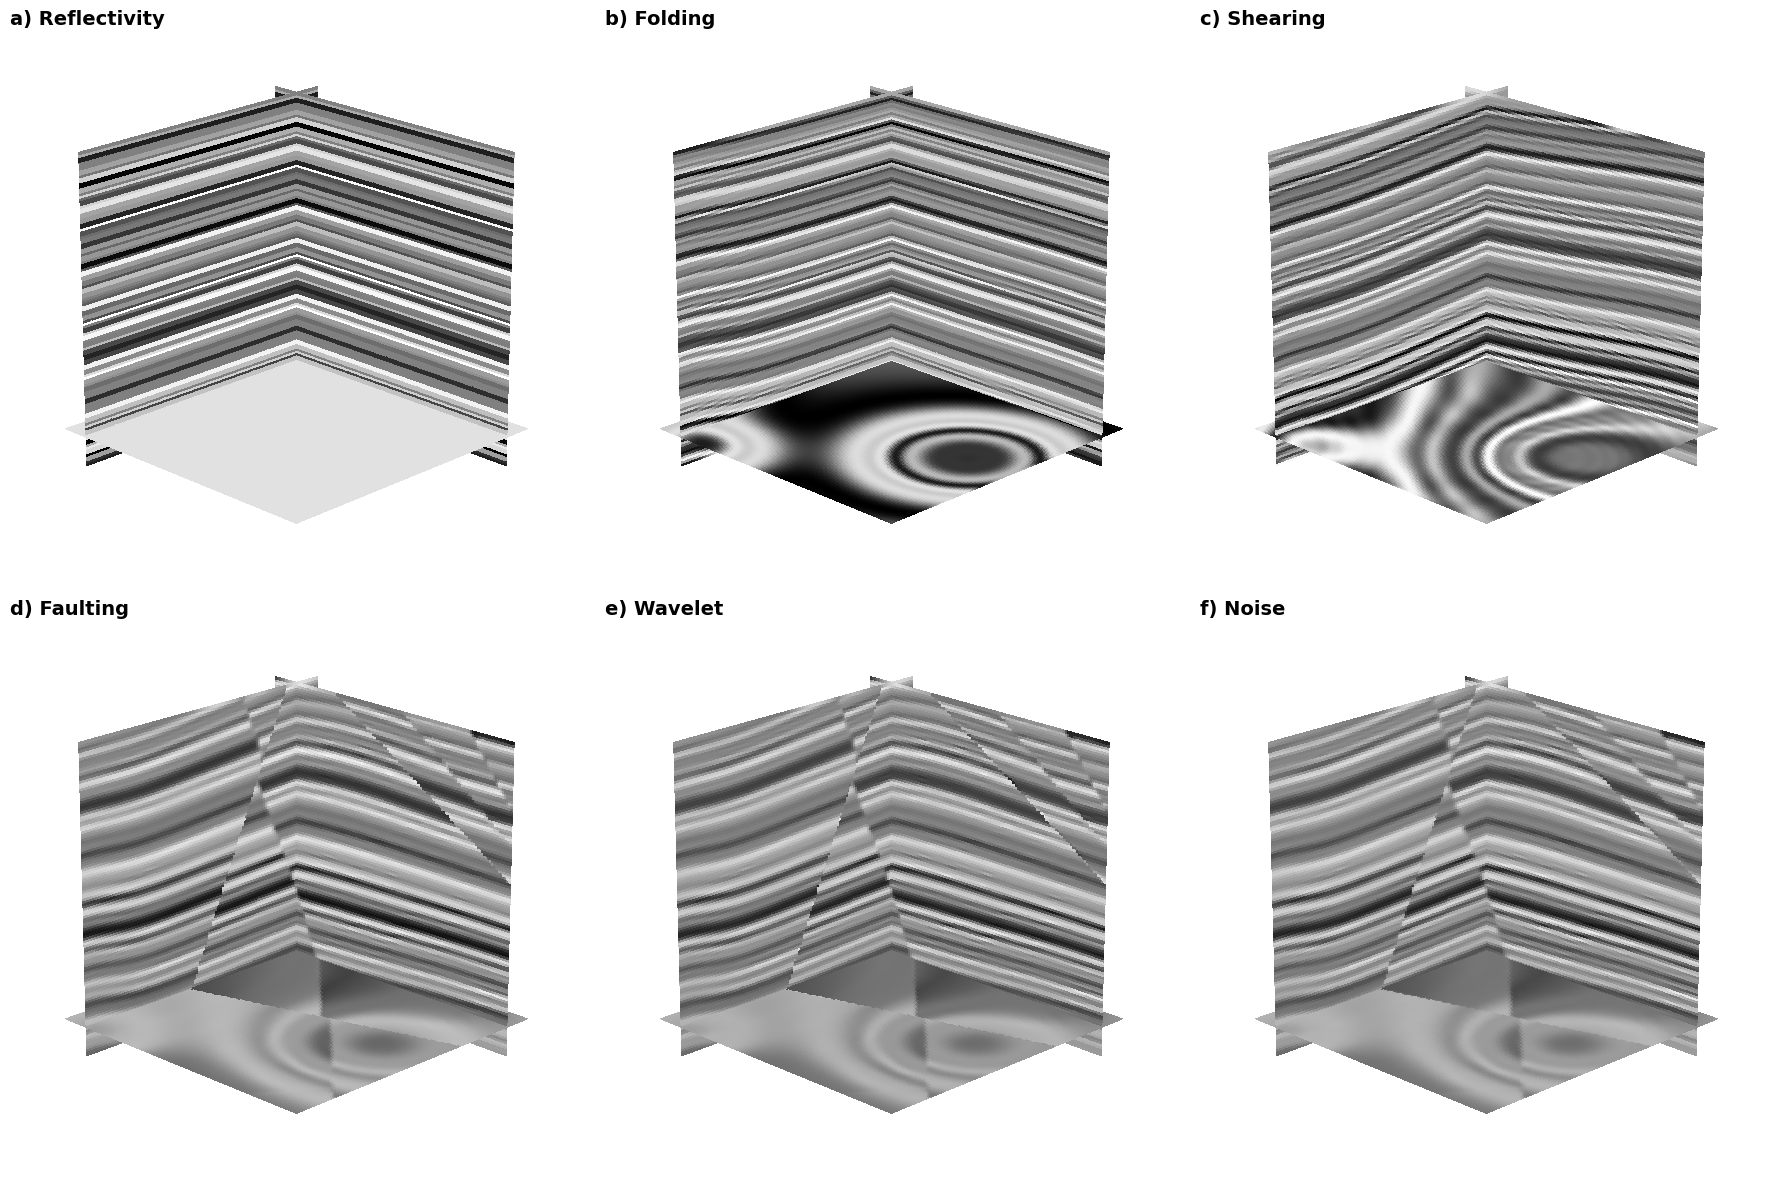

In [ ]:
for i in range(10):
    gen = SyntheticGenerator()
    gen.set(best_options)

    reflectivity = gen.genReflectivity()
    folded  = gen.applyFolding(reflectivity)
    sheared = gen.applyShearing(folded)
    faulted, mask = gen.applyFaulting(sheared)
    seismic = gen.applyWavelet(faulted)
    noisy   = gen.applyNoise(seismic)

    steps = [
        (gen.crop(reflectivity), 'a) Reflectivity'),
        (gen.crop(folded),       'b) Folding'),
        (gen.crop(sheared),      'c) Shearing'),
        (gen.crop(faulted),      'd) Faulting'),
        (gen.crop(seismic),      'e) Wavelet'),
        (gen.crop(noisy),        'f) Noise'),
    ]
    
    showSteps(steps)